## Short Term Memory Summarization


Import all the required modules

In [7]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

define the model

In [3]:
model = ChatOpenAI()

Define the state for the graph


Here along with the builtin MessagesState ( which contains various list of messages such as Human, AI, system etc etc), we will inherit it and then add another variable called summary

In [4]:
class ChatState(MessagesState):
    summary: str

Define the nodes for the graph

1. First one to add the summary to list of messages and pass it to model to get a response
2. One more to actually generate a summary of all the messages till now ( This will be a conditional node which will trigger only when context limit set by us is reached )
3. Conditional Node which decides when to summarize.

In [5]:
#Lets define the node which adds the summary to the list of messages
def chat_node(state: ChatState):
    messages =[]

    #If the summary already exists, then we will add that summary to the new messages list as the first message
    if state["summary"]:
        messages.append({
            "role":"system",
            "content": f"Conversation summary: \n { state['summary']}"
        })

    #Then after adding summary as the first message, we will add the remaining messages that are present in the state already
    messages.extend(state["messages"])

    #We will look at them to see how it all looks like
    print(messages)

    #Now we will pass this whole updated list to the model and get the response
    response = model.invoke(messages)

    #Now we will partially update the state by adding this latest response to all the messages
    #Inbuilt MessageState class takes care of the reducer, it knows internally that it should append the messages list with the response
    return {"messages": [response]}


#Lets define the node which generates the summary
def summarize_conversation(state: ChatState):

    #here even if its empty we will first get it
    existing_summary = state["summary"]

    #Build a summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary: \n{existing_summary} \n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    #Here we are adding the messages before the prompt and sending to the model
    #So that it will summarize all the messages above the prompt, since we literally said above
    messages_for_summary = state["messages"] + [HumanMessage(content= prompt)]

    #Now lets send it to the model
    response = model.invoke(messages_for_summary)

    #Select all the messages except the last 2 messages
    messages_to_delete = state["messages"][:-2]

    #Here we will summarize the messages and then use the RemoveMessage reducer on the messages list of the state 
    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete]
    }


Now, define the function which should be passed to the conditional edge

In [6]:
#Define the conditional function 
def should_summarize(state: ChatState):

    #Just check if the length exceeds 6 and then return true
    return len(state["messages"]) > 6

Now, lets build the graph


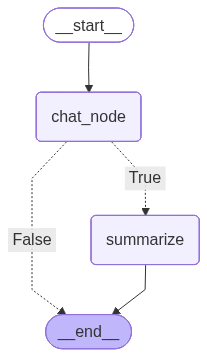

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat_node", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges(
    "chat_node",
    should_summarize,
    {
        True: "summarize",
        False: END
    }
)

builder.add_edge("summarize", END)

checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)
graph

Now, lets test the graph

First define the config variable for adding a thread-id, since we have an in - memory saver

In [10]:
config = {"configurable": {"thread_id": "t1"}}

Lets define a custom function, which simply prints whats present in the entire state of the graph anytime its called.

In [11]:
def show_state():

    snap = graph.get_state(config)
    vals = snap.values 
    
    print("\n-----STATE------")
    print("summary : ", vals.get("summary", ""))
    print("num_messages : ", len(vals.get('messages',[])))
    print("messages : ")
    for m in vals.get("messages", []):
        print("-", type(m).__name__,":",m.content[:80])

Now lets begin the actual testing

In [12]:
out = graph.invoke({
                    "messages": [HumanMessage(content='Quantum Physics')],
                    "summary": ""
                   },
                   config = config
)

print(out)

show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8e27cbbc-0c6e-4bde-ad11-f1df6d493904')]
{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8e27cbbc-0c6e-4bde-ad11-f1df6d493904'), AIMessage(content='Quantum physics is the branch of physics that studies the behavior of matter and energy at a very small scale, such as the level of atoms and subatomic particles. It is based on the principles of quantum theory, which describes the fundamental interactions of particles and energy in terms of quantum phenomena such as superposition, entanglement, and wave-particle duality.\n\nQuantum physics has led to the development of many important technologies, such as quantum computers and quantum cryptography. It has also provided valuable insights into the nature of reality and the fundamental laws of the universe.\n\nSome of the key concepts in quantum physics include:\n\n- Wave-particle duality: The idea that

In [13]:
out = graph.invoke({
                    "messages": [HumanMessage(content='How is Albert Einstein related to Quantum Physics')],
                    "summary": ""
                   },
                   config = config
)

print(out)

show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8e27cbbc-0c6e-4bde-ad11-f1df6d493904'), AIMessage(content='Quantum physics is the branch of physics that studies the behavior of matter and energy at a very small scale, such as the level of atoms and subatomic particles. It is based on the principles of quantum theory, which describes the fundamental interactions of particles and energy in terms of quantum phenomena such as superposition, entanglement, and wave-particle duality.\n\nQuantum physics has led to the development of many important technologies, such as quantum computers and quantum cryptography. It has also provided valuable insights into the nature of reality and the fundamental laws of the universe.\n\nSome of the key concepts in quantum physics include:\n\n- Wave-particle duality: The idea that particles such as electrons exhibit both wave-like and particle-like properties.\n- Superposition: The ability of quantum particles to exist 

In [14]:
out = graph.invoke({
                    "messages": [HumanMessage(content='Explain Special Therory of relativity')],
                    "summary": ""
                   },
                   config = config
)

print(out)

show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8e27cbbc-0c6e-4bde-ad11-f1df6d493904'), AIMessage(content='Quantum physics is the branch of physics that studies the behavior of matter and energy at a very small scale, such as the level of atoms and subatomic particles. It is based on the principles of quantum theory, which describes the fundamental interactions of particles and energy in terms of quantum phenomena such as superposition, entanglement, and wave-particle duality.\n\nQuantum physics has led to the development of many important technologies, such as quantum computers and quantum cryptography. It has also provided valuable insights into the nature of reality and the fundamental laws of the universe.\n\nSome of the key concepts in quantum physics include:\n\n- Wave-particle duality: The idea that particles such as electrons exhibit both wave-like and particle-like properties.\n- Superposition: The ability of quantum particles to exist 

Now, lets add more messsages and increase the length to 6, so that our summary will get triggered and generated

In [15]:
out = graph.invoke({
                    "messages": [HumanMessage(content='What is Einsteins some of the famous work?')],
                    "summary": ""
                   },
                   config = config
)

print(out)

show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8e27cbbc-0c6e-4bde-ad11-f1df6d493904'), AIMessage(content='Quantum physics is the branch of physics that studies the behavior of matter and energy at a very small scale, such as the level of atoms and subatomic particles. It is based on the principles of quantum theory, which describes the fundamental interactions of particles and energy in terms of quantum phenomena such as superposition, entanglement, and wave-particle duality.\n\nQuantum physics has led to the development of many important technologies, such as quantum computers and quantum cryptography. It has also provided valuable insights into the nature of reality and the fundamental laws of the universe.\n\nSome of the key concepts in quantum physics include:\n\n- Wave-particle duality: The idea that particles such as electrons exhibit both wave-like and particle-like properties.\n- Superposition: The ability of quantum particles to exist 